K- Means Clustering Without Elbow Method

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

In [6]:
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)


In [7]:
X = df[['sepal length (cm)', 'sepal width (cm)']].values

In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [13]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

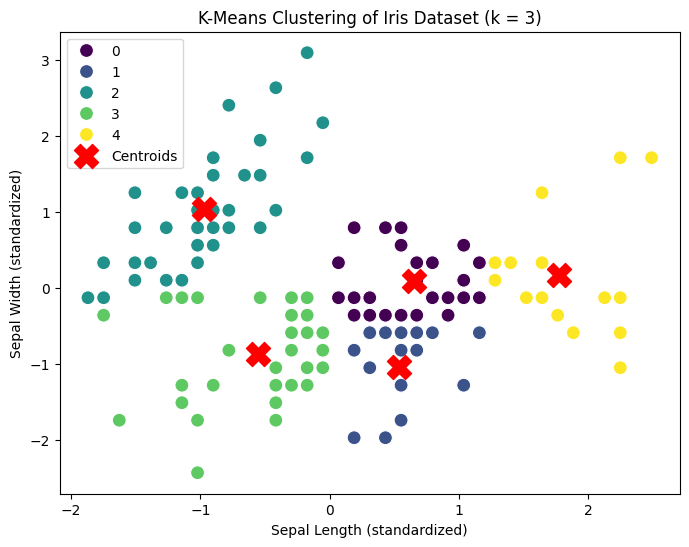

In [18]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_scaled[:,0], y=X_scaled[:,1], hue=y_kmeans, palette='viridis', s=100)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='red', label='Centroids', marker='X')
plt.xlabel('Sepal Length (standardized)')
plt.ylabel('Sepal Width (standardized)')
plt.title('K-Means Clustering of Iris Dataset (k = 3)')
plt.legend()
plt.show()

k-means clustering eibow method


-the eibow method is technique used to determine the optmimal number of clusters k in k -means clustering.
-it does this by analyzing the within cluster sum of squares (wcss), which measures the tottal varience within each cluster.



In [22]:
wcss = []
k_values = range(1, 11)



for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)


In [23]:
pip install kneed

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
from kneed import KneeLocator
knee_locator = KneeLocator(k_values, wcss, curve='convex', direction='decreasing')
optimal_k = knee_locator.elbow

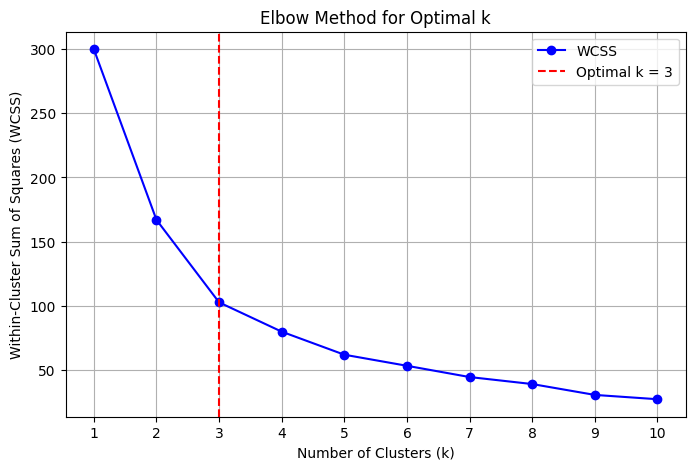

The optimal number of clusters determined by the Elbow Method is: 3


In [29]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, wcss, marker='o', linestyle='-', color='b', label='WCSS')
plt.axvline(optimal_k, color='red', linestyle='--', label=f'Optimal k = {optimal_k}')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.title('Elbow Method for Optimal k')     
plt.xticks(k_values)
plt.legend()
plt.grid()
plt.show()
print(f"The optimal number of clusters determined by the Elbow Method is: {optimal_k}")
